In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset

# as only this sheet have actual data that need to be clean rest is matadata and key trends
df_perf = pd.read_excel("tfl-tube-performance.xlsx", sheet_name="Lost customer hours")


In [ ]:
#Show all column names
df_perf.columns

Index(['Financial Year', 'Period 1', 'Period 2', 'Period 3', 'Period 4',
       'Period 5', 'Period 6', 'Period 7', 'Period 8', 'Period 9', 'Period 10',
       'Period 11', 'Period 12', 'Period 13'],
      dtype='object')

In [ ]:
#Look at the first few rows (the table)
df_perf.head()

,Financial Year,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11,Period 12,Period 13
0,2003/04,3.257855e+06,3.425283e+06,3.859340e+06,4.127866e+06,4.447877e+06,4.503476e+06,4.467453e+06,5.494806e+06,4.123132e+06,2.791979e+06,3.742198e+06,3.735764e+06,4290990.846802
1,2004/05,3.844130e+06,3.342358e+06,3.507979e+06,5.410752e+06,4.089718e+06,2.892844e+06,2.983461e+06,3.176544e+06,2.939043e+06,2.379839e+06,2.928793e+06,4.080491e+06,3272562.299139
2,2005/06,3.139284e+06,4.025029e+06,3.620728e+06,1.323250e+07,7.710007e+06,4.053470e+06,5.550098e+06,3.817617e+06,3.704433e+06,3.147906e+06,4.102229e+06,3.605636e+06,3128081.813063
3,2006/07,2.897442e+06,2.918580e+06,3.321016e+06,4.194887e+06,3.777136e+06,3.557078e+06,3.054899e+06,3.643299e+06,4.637673e+06,2.540301e+06,3.384482e+06,4.526399e+06,3214634.428441
4,2007/08,4.068427e+06,3.632000e+06,3.398354e+06,4.495051e+06,3.758561e+06,6.355312e+06,3.566168e+06,3.521699e+06,3.335743e+06,3.114138e+06,3.418314e+06,3.535057e+06,2859022.375098


In [ ]:
#Make column names simple
df_perf.columns = df_perf.columns.str.strip().str.lower().str.replace(" ", "_")
df_perf.columns


Index(['financial_year', 'period_1', 'period_2', 'period_3', 'period_4',
       'period_5', 'period_6', 'period_7', 'period_8', 'period_9', 'period_10',
       'period_11', 'period_12', 'period_13'],
      dtype='object')

In [ ]:
#Convert numbers (simple version)
#Each period column contains numbers with commas.lets clean them one by one.
for col in df_perf.columns:
    if col != "financial_year":
        df_perf[col] = df_perf[col].astype(str).str.replace(",", "")
        df_perf[col] = pd.to_numeric(df_perf[col], errors="coerce")


In [ ]:
#Check the cleaned table
df_perf.head()

,financial_year,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10,period_11,period_12,period_13
0,2003/04,3.257855e+06,3.425283e+06,3.859340e+06,4.127866e+06,4.447877e+06,4.503476e+06,4.467453e+06,5.494806e+06,4.123132e+06,2.791979e+06,3.742198e+06,3.735764e+06,4.290991e+06
1,2004/05,3.844130e+06,3.342358e+06,3.507979e+06,5.410752e+06,4.089718e+06,2.892844e+06,2.983461e+06,3.176544e+06,2.939043e+06,2.379839e+06,2.928793e+06,4.080491e+06,3.272562e+06
2,2005/06,3.139284e+06,4.025029e+06,3.620728e+06,1.323250e+07,7.710007e+06,4.053470e+06,5.550098e+06,3.817617e+06,3.704433e+06,3.147906e+06,4.102229e+06,3.605636e+06,3.128082e+06
3,2006/07,2.897442e+06,2.918580e+06,3.321016e+06,4.194887e+06,3.777136e+06,3.557078e+06,3.054899e+06,3.643299e+06,4.637673e+06,2.540301e+06,3.384482e+06,4.526399e+06,3.214634e+06
4,2007/08,4.068427e+06,3.632000e+06,3.398354e+06,4.495051e+06,3.758561e+06,6.355312e+06,3.566168e+06,3.521699e+06,3.335743e+06,3.114138e+06,3.418314e+06,3.535057e+06,2.859022e+06


In [ ]:
#Fix display to show full numbers (no scientific notation)
pd.set_option('display.float_format', lambda x: '%.0f' % x)


In [ ]:
df_perf.head()

,financial_year,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10,period_11,period_12,period_13
0,2003/04,3257855,3425283,3859340,4127866,4447877,4503476,4467453,5494806,4123132,2791979,3742198,3735764,4290991
1,2004/05,3844130,3342358,3507979,5410752,4089718,2892844,2983461,3176544,2939043,2379839,2928793,4080491,3272562
2,2005/06,3139284,4025029,3620728,13232497,7710007,4053470,5550098,3817617,3704433,3147906,4102229,3605636,3128082
3,2006/07,2897442,2918580,3321016,4194887,3777136,3557078,3054899,3643299,4637673,2540301,3384482,4526399,3214634
4,2007/08,4068427,3632000,3398354,4495051,3758561,6355312,3566168,3521699,3335743,3114138,3418314,3535057,2859022


In [ ]:
df_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   financial_year  17 non-null     object 
 1   period_1        17 non-null     float64
 2   period_2        17 non-null     float64
 3   period_3        17 non-null     float64
 4   period_4        17 non-null     float64
 5   period_5        17 non-null     float64
 6   period_6        17 non-null     float64
 7   period_7        17 non-null     float64
 8   period_8        17 non-null     float64
 9   period_9        17 non-null     float64
 10  period_10       17 non-null     float64
 11  period_11       17 non-null     float64
 12  period_12       17 non-null     float64
 13  period_13       16 non-null     float64
dtypes: float64(13), object(1)
memory usage: 2.0+ KB


In [ ]:
df_perf.columns


Index(['financial_year', 'period_1', 'period_2', 'period_3', 'period_4',
       'period_5', 'period_6', 'period_7', 'period_8', 'period_9', 'period_10',
       'period_11', 'period_12', 'period_13'],
      dtype='object')

In [ ]:
#Filter years (2011–2020)
df_perf = df_perf[df_perf["financial_year"] >= "2011/12"]
df_perf


,financial_year,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10,period_11,period_12,period_13
8,2011/12,2509354,2322089,1929445,2300769,2059198,2462085,2155102,2054499,1989066,2043901,2073884,2604341,1997431
9,2012/13,1976896,2398403,2453427,1745717,1728724,1100217,1253385,1656899,1726294,1461084,1831202,1709469,1815754
10,2013/14,1674459,1332503,1534174,1838159,1749066,1401638,1684080,1932919,1731747,1420964,1522310,4932056,1467235
11,2014/15,1232270,4400900,1431679,1467461,1528313,2111445,1787750,1449503,1794842,1165182,1513254,1447954,1331204
12,2015/16,1679343,1048174,1393156,4916461,5225844,1673474,1642033,1523639,1697720,808160,1505232,1496334,1847729
13,2016/17,1839941,1658274,2080947,2542255,2005243,2199866,1970358,2269091,4613544,2378655,2440101,2233238,2032259
14,2017/18,1972225,2309084,2742884,2698591,2457382,2434941,2598106,2278197,2782576,2232045,2450386,3014669,2795361
15,2018/19,2515368,2122222,2543993,2415713,2596055,1920940,2436016,2821206,2627007,1813387,2315609,2414352,2552718
16,2019/20,2511502,2356450,2777924,3284529,3549064,3711898,3892833,4456402,4893441,3134042,2974395,3563948,NaN


In [ ]:
#Reshape the dataset Right now your dataset is wide but we need long format for analysis, SQL, PowerBI
df_long = df_perf.melt(
    id_vars="financial_year",
    var_name="period",
    value_name="lost_customer_hours"
)
df_long.head()


,financial_year,period,lost_customer_hours
0,2011/12,period_1,2509354
1,2012/13,period_1,1976896
2,2013/14,period_1,1674459
3,2014/15,period_1,1232270
4,2015/16,period_1,1679343


In [ ]:
#Clean the period column
df_long["period"] = df_long["period"].str.replace("period_", "")
df_long.head()


,financial_year,period,lost_customer_hours
0,2011/12,1,2509354
1,2012/13,1,1976896
2,2013/14,1,1674459
3,2014/15,1,1232270
4,2015/16,1,1679343


In [ ]:
#Convert period to number
df_long["period"] = pd.to_numeric(df_long["period"])


In [ ]:
#Final check
df_long.info()
df_long.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   financial_year       117 non-null    object 
 1   period               117 non-null    int64  
 2   lost_customer_hours  116 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.9+ KB


,financial_year,period,lost_customer_hours
0,2011/12,1,2509354
1,2012/13,1,1976896
2,2013/14,1,1674459
3,2014/15,1,1232270
4,2015/16,1,1679343
5,2016/17,1,1839941
6,2017/18,1,1972225
7,2018/19,1,2515368
8,2019/20,1,2511502
9,2011/12,2,2322089


In [ ]:
#Check the dataset shape
df_long.shape


(117, 3)

In [ ]:
#Sort the data (simple), This ensures the data is in correct time order.
df_long = df_long.sort_values(["financial_year", "period"])
df_long.head(20)


,financial_year,period,lost_customer_hours
0,2011/12,1,2509354
9,2011/12,2,2322089
18,2011/12,3,1929445
27,2011/12,4,2300769
36,2011/12,5,2059198
45,2011/12,6,2462085
54,2011/12,7,2155102
63,2011/12,8,2054499
72,2011/12,9,1989066
81,2011/12,10,2043901


In [ ]:
#Basic analysis: total lost hours per year
df_long.groupby("financial_year")["lost_customer_hours"].sum()
#This gives:total lost customer hours per financial year perfect for a trend chart later

financial_year
2011/12   28501165
2012/13   22857471
2013/14   24221310
2014/15   22661757
2015/16   26457299
2016/17   30263772
2017/18   32766447
2018/19   31094587
2019/20   41106428
Name: lost_customer_hours, dtype: float64

In [ ]:
#Basic analysis: total lost hours per period
df_long.groupby("period")["lost_customer_hours"].sum()
#this gives:which periods have the highest delays useful for operational insights

period
1    17911358
2    19948100
3    18887628
4    23209655
5    22898890
6    19016506
7    19419662
8    20442355
9    23856236
10   16457421
11   18626373
12   23416360
13   15839691
Name: lost_customer_hours, dtype: float64

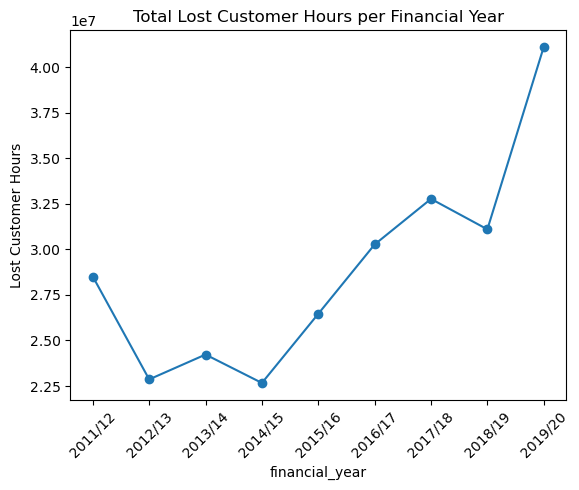

In [ ]:
#Plot a simple trend line chart
import matplotlib.pyplot as plt

df_long.groupby("financial_year")["lost_customer_hours"].sum().plot(kind="line", marker="o")
plt.title("Total Lost Customer Hours per Financial Year")
plt.xticks(rotation=45)
plt.ylabel("Lost Customer Hours")
plt.show()


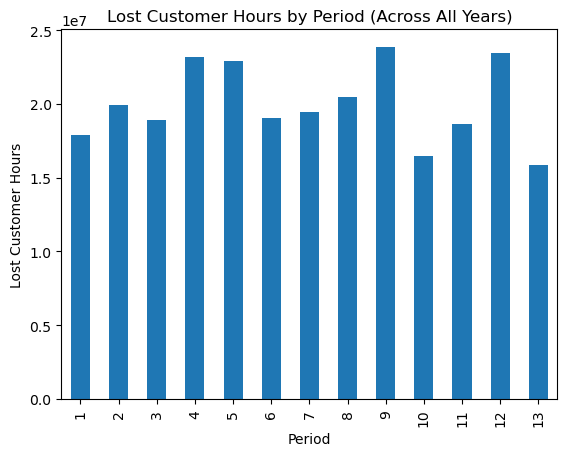

In [ ]:
#Period trend chart
df_long.groupby("period")["lost_customer_hours"].sum().plot(kind="bar")
plt.title("Lost Customer Hours by Period (Across All Years)")
plt.xlabel("Period")
plt.ylabel("Lost Customer Hours")
plt.show()


<Axes: xlabel='period', ylabel='financial_year'>

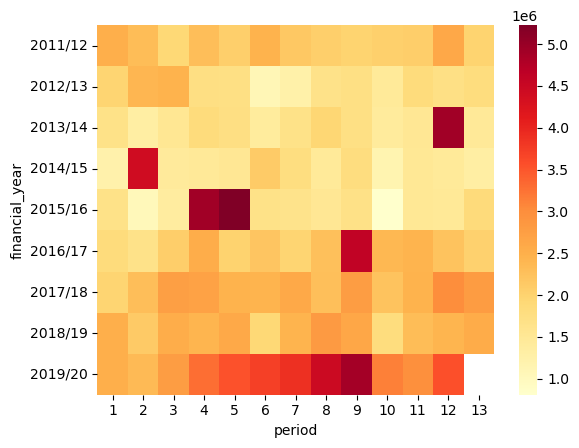

In [ ]:
#Year + Period heatmap
import seaborn as sns

pivot = df_long.pivot(index="financial_year", columns="period", values="lost_customer_hours")
sns.heatmap(pivot, cmap="YlOrRd")


In [ ]:
#Create a KPI: YoY change
df_year = df_long.groupby("financial_year")["lost_customer_hours"].sum().reset_index()
df_year["yoy_change"] = df_year["lost_customer_hours"].pct_change() * 100
df_year


,financial_year,lost_customer_hours,yoy_change
0,2011/12,28501165,NaN
1,2012/13,22857471,-20
2,2013/14,24221310,6
3,2014/15,22661757,-6
4,2015/16,26457299,17
5,2016/17,30263772,14
6,2017/18,32766447,8
7,2018/19,31094587,-5
8,2019/20,41106428,32


In [ ]:
#Save clean dataset
df_long.to_csv("clean_lost_customer_hours.csv", index=False)
